# Training PPO Tiny Tackers
Run on Google Colab for superior training efficiency
I recommend the T4 GPU

- - - - - - - - - - - - - - - - - - - - - - - -
## Train on gym_sail_steps SailboatReachRounding Environment

This notebook goes through the learning tasks in the same order required for the boat to complete a Triangle Racecourse. Each leg of that race demands that the PPO agent learn new skills.

The first learning task is to complete the environment built by Gabo Tor as this environment is the inspiration for the project. Subsequent learning tasks are all trained in environments created by yours truly. They are as follows:

    1. Start near the leeward buoy and reach the target point at the windward buoy
    2. Start near the windward buoy and reach the target point at the reach buoy
    3. Start near the reach buoy and reach the target point at the leeward buoy
    4. Start near the windward buoy and round the reach buoy finishing at the leeward buoy, all while chasing target points that are designed to encourage jibing
    5. Start near the windward buoy and reach the target point near the leeward buoy
    6. Hit every target point in a triangle race course by rounding all the buoys
- - - - - - - - - - - - - - - - - - - - - - - -



#####
#####
# *"Sailing is the art of going nowhere slowly, at great expense"*
*- The sailing community*


#####
#####
#####
#####

- - - - - - - - - - - - - - - - - - - -
# Training a PPO Baseline Model on Gabo-Tor Environment
- Learning Outcome: The Tiny Tacker must learn how to sail into the wind on a close haul while also learning to tack (turn through the wind without getting stuck in irons)
  1. Reach the Windward Buoy to Finish
- - - - - - - - - - - - - - - - - - - -

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Set directory to tiny_tackers
%cd "/content/drive/My Drive/tiny_tackers"

/content/drive/My Drive/tiny_tackers


In [3]:
# Install and import dependencies
!pip install stable-baselines3 gymnasium pygame

import os
import sys
import time
import pandas as pd
import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

from gymnasium.wrappers import RecordVideo

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# Set path to retrieving the base environment
BASE_ENV_PATH = "/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sailing_gabo-tor"
sys.path.append(BASE_ENV_PATH)

In [5]:
# Import environment and ensure it's comming from the correct path. Ending in tiny_tackers/gym_sailing_environments/gym_sailing_gabo-tor/gym_sailing/__init__.py
import gym_sailing
print(gym_sailing.__file__)

/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sailing_gabo-tor/gym_sailing/__init__.py


In [6]:
# Specifify that the environment is going to be one where continuous actions are possible
ENV_ID = "Sailboat-v0"

In [7]:
# Create directory for storing your model, videos, and metrics
models_dir = "models/ppo/base"
videos_dir = "videos/ppo/base"
metrics_dir = "metrics"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(videos_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

In [8]:
# Make and define training and evaluation environments (render mode is none because vizualizing significantly slows down training and evaluation)
def make_env(render_mode=None):
    env = gym.make(ENV_ID, render_mode=render_mode)
    env = Monitor(env)
    return env

train_env = make_env()
eval_env = make_env()

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

In [9]:
# Improve efficiency with parallel environments
from stable_baselines3.common.env_util import make_vec_env
train_env = make_vec_env(lambda: make_env(), n_envs=4)

In [10]:
# Train PPO for 1_000_000 timesteps and save the training time in seconds
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    gamma=0.99,
    verbose=1,
)

start = time.time()
model.learn(
    total_timesteps=1_000_000,
    progress_bar=True,
)

training_time_seconds = time.time() - start

Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
|    loss                 | 13.5         |
|    n_updates            | 150          |
|    policy_gradient_loss | -0.000748    |
|    std                  | 0.998        |
|    value_loss           | 36.6         |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 640          |
|    ep_rew_mean          | -230         |
| time/                   |              |
|    fps                  | 870          |
|    iterations           | 17           |
|    time_elapsed         | 80           |
|    total_timesteps      | 69632        |
| train/                  |              |
|    approx_kl            | 0.0026482742 |
|    clip_fraction        | 0.0229       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | 0.842        |
|    learning_rate        | 0.0003       |
|  

In [11]:
# Evaluate and capture average episode length and rewards over 20 episodes and view the results
episode_rewards, episode_lengths = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
)

mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = pd.Series(episode_rewards).std()

mean_episode_timesteps = sum(episode_lengths) / len(episode_lengths)
std_episode_timesteps = pd.Series(episode_lengths).std()

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)
print("Mean episode timesteps:", mean_episode_timesteps)
print("Std episode timesteps:", std_episode_timesteps)
print("Training time seconds:", training_time_seconds)

Mean reward: 361.92136895
Std reward: 6.715062555944596
Mean episode timesteps: 1202.75
Std episode timesteps: 60.79722552533913
Training time seconds: 1177.0103106498718


In [12]:
# Save the base model if you are satisfied
model_path = f"{models_dir}/ppo_gabo-tor_base_1M"
model.save(model_path)

print(f"Saved model to: {model_path}.zip")

Saved model to: models/ppo/base/ppo_gabo-tor_base_1M.zip


In [13]:
# Save metrics if you are satisfied, or if you need to run this again and compare runs
metrics = pd.DataFrame([{
    "env_id": ENV_ID,
    "model": "PPO",
    "training_timesteps": 1_000_000,
    "n_eval_episodes": 20,
    "mean_reward": mean_reward,
    "std_reward": std_reward,
    "mean_episode_timesteps": mean_episode_timesteps,
    "std_episode_timesteps": std_episode_timesteps,
    "training_time_seconds": training_time_seconds,
}])

metrics_path = f"{metrics_dir}/ppo_base_metrics.csv"

if os.path.exists(metrics_path):
    old = pd.read_csv(metrics_path)
    metrics = pd.concat([old, metrics], ignore_index=True)

metrics.to_csv(metrics_path, index=False)
metrics

,env_id,model,training_timesteps,n_eval_episodes,mean_reward,std_reward,mean_episode_timesteps,std_episode_timesteps,training_time_seconds
0,Sailboat-v0,PPO,1000000,20,361.921369,6.715063,1202.75,60.797226,1177.010311


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
# Record video an evaluation episode of the trained model and save it in the videos directory with a name prefix of ppo_base_trained. The video should be saved as a mp4 file and should be named ppo_base_trained_episode_0.mp4.
video_env = gym.make(ENV_ID, render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=videos_dir,
    name_prefix="ppo_gabo-tor_base_1M",
    episode_trigger=lambda episode_id: episode_id == 0,
)

obs, info = video_env.reset()
done = False
truncated = False

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
video_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/tiny_tackers/videos/ppo/base folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Navigate to your videos folder and watch the video
You can mess with the hyperparameters or timesteps to try and improve your result.
I recommend the papers cited in the README.

---
END

---

---
# Upwind Environment PPO Training
### (*Using the gym_sail_steps SailboatUpwind Environment*)
---

###Learning Task: Similarly to the Gabo Tor environment, the agent must learn to sail from a leeward point to a target at the windward buoy
    1. The agent must learn to head towards the target (rounding point - green dot)
    2. The agent must learn how to mange points of sail and prevent getting stuck in "irons" (irons is when you are heading directly into the wind and begin to go backwards)
    3. The agent must optimize a path, you can make many or few turns. A good sailor tries to make as few turns as possible in order to maximize speed.
    4. All this must be managed while starting closer to the boundary of the environment because we are training for the traingle race.
---

Note: Some of the code you will see below is redundant; it's there intentionally so that you may start at any point if you have a previously saved model.
For instance, you may not need to "mount" the drive in every section, but it's there in case you wanted to start at this point in the process.

In [13]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Confirm my repo location
%cd "/content/drive/My Drive/tiny_tackers"
!pwd

/content/drive/My Drive/tiny_tackers
/content/drive/My Drive/tiny_tackers


In [15]:
# Install Stable Baselines3 library if not already installed
!pip install stable-baselines3 gymnasium pygame

In [16]:
# Confirm necessary libraries and imports are installed if they weren't already
import os
import sys
import time
import pandas as pd
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env
from gymnasium.wrappers import RecordVideo

In [17]:
# Set Path to the gym_sail_steps environments
STEPS_ENV_PATH = "/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps"
sys.path.append(STEPS_ENV_PATH)

In [18]:
# IMPORTANT! Import steps environments and ensure it's coming from the correct path. Ending in tiny_tackers/gym_sailing_environments/gym_sailing_race/gym_sail_race/__init__.py
import gym_sail_steps
print(gym_sail_steps.__file__)

/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py


In [19]:
# Identify the upwind environment to call for this section
ENV_ID = "SailboatUpwind-v0"

In [20]:
# Make folders for outcomes if folders do not already exist.
models_dir = "models/ppo/upwind_step"
videos_dir = "videos/ppo/upwind_step"
metrics_dir = "metrics"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(videos_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

In [21]:
# Define the make environment function environments (render mode is none because visualizing significantly slows down training and evaluation)
def make_env(render_mode=None):
    env = gym.make(ENV_ID, render_mode=render_mode)
    env = Monitor(env)
    return env


In [22]:
# Improve efficiency with parallel environments, create your training environment
from stable_baselines3.common.env_util import make_vec_env
train_env = make_vec_env(lambda: make_env(), n_envs=4)

In [23]:
# Make evaluation environment
eval_env = make_env()

In [25]:
# Train PPO for 1_000_000 timesteps and save the training time in seconds
# Hyperparameters inspired by PPO Paper used in Stablebaselines3, link in the Readme. I ultimately decided to keep a high gamma and reduced n_steps to 1024.
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.0,
    vf_coef=0.5,
    max_grad_norm=0.5,
)

start = time.time()
model.learn(
    total_timesteps=1_000_000,
    progress_bar=True,
)

training_time_seconds = time.time() - start

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [26]:
# Evaluate and capture average episode length and rewards over 20 episodes
episode_rewards, episode_lengths = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
)

mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = pd.Series(episode_rewards).std()

mean_episode_timesteps = sum(episode_lengths) / len(episode_lengths)
std_episode_timesteps = pd.Series(episode_lengths).std()

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)
print("Mean episode timesteps:", mean_episode_timesteps)
print("Std episode timesteps:", std_episode_timesteps)
print("Training time seconds:", training_time_seconds)

Mean reward: 308.60709415
Std reward: 26.25599521134129
Mean episode timesteps: 1301.1
Std episode timesteps: 260.3796620726216
Training time seconds: 1230.1502771377563


In [27]:
# Save the upwind model
model_path = f"{models_dir}/ppo_upwind_step_1M"
model.save(model_path)

print(f"Saved model to: {model_path}.zip")

Saved model to: models/ppo/upwind_step/ppo_upwind_step_1M.zip


In [28]:
# Save metrics
metrics = pd.DataFrame([{
    "env_id": ENV_ID,
    "model": "PPO",
    "training_timesteps": 1_000_000,
    "n_eval_episodes": 20,
    "mean_reward": mean_reward,
    "std_reward": std_reward,
    "mean_episode_timesteps": mean_episode_timesteps,
    "std_episode_timesteps": std_episode_timesteps,
    "training_time_seconds": training_time_seconds,
}])

metrics_path = f"{metrics_dir}/ppo_upwind_metrics.csv"

if os.path.exists(metrics_path):
    old = pd.read_csv(metrics_path)
    metrics = pd.concat([old, metrics], ignore_index=True)

metrics.to_csv(metrics_path, index=False)
metrics

,env_id,model,training_timesteps,n_eval_episodes,mean_reward,std_reward,mean_episode_timesteps,std_episode_timesteps,training_time_seconds
0,SailboatUpwind-v0,PPO,1000000,20,308.607094,26.255995,1301.1,260.379662,1230.150277


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
# Record video an evaluation episode of the trained model and save it in the videos directory with a name prefix of ppo_base_trained. The video should be saved as a mp4 file and should be named ppo_base_trained_episode_0.mp4.
video_env = gym.make(ENV_ID, render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=videos_dir,
    name_prefix="ppo_upwind_step_1M",
    episode_trigger=lambda episode_id: episode_id == 0,
)

obs, info = video_env.reset()
done = False
truncated = False

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
video_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/tiny_tackers/videos/ppo/upwind_step folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


---
END

---


---
# Windward to Reach Environment PPO Training
### (*Using the gym_sail_steps SailboatWindwardToReach Environment*)
---

###Learning Task: In this task the agent will get comfortable with traveling from the windward buoy location to the reach buoy location
    1. The agent must learn that it's ok not to turn, and to travel at a broach reach approx 135 degrees to the wind (if measuring counterclockwise)
---


In [15]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Confirm my repo location
%cd "/content/drive/My Drive/tiny_tackers"
!pwd

/content/drive/My Drive/tiny_tackers
/content/drive/My Drive/tiny_tackers


In [17]:
# Install Stable Baselines3 library if not already installed
!pip install stable-baselines3 gymnasium pygame

In [18]:
# Confirm necessary libraries and imports are installed if they weren't already
import os
import sys
import time
import pandas as pd
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env
from gymnasium.wrappers import RecordVideo

In [19]:
# Set Path to the gym_sail_steps environments
STEPS_ENV_PATH = "/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps"
sys.path.append(STEPS_ENV_PATH)

In [20]:
# IMPORTANT! Import steps environments and ensure it's coming from the correct path. Ending in tiny_tackers/gym_sailing_environments/gym_sailing_race/gym_sail_race/__init__.py
import gym_sail_steps
print(gym_sail_steps.__file__)

/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py


In [21]:
# Identify the environment to call for this section
ENV_ID = "SailboatWindwardToReach-v0"

In [22]:
# Make folders for outcomes if folders do not already exist.
models_dir = "models/ppo/windward_to_reach_step"
videos_dir = "videos/ppo/windward_to_reach_step"
metrics_dir = "metrics"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(videos_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

In [23]:
# Define the make environment function environments (render mode is none because visualizing significantly slows down training and evaluation)
def make_env(render_mode=None):
    env = gym.make(ENV_ID, render_mode=render_mode)
    env = Monitor(env)
    return env


In [24]:
# Improve efficiency with parallel environments, create your training environment
from stable_baselines3.common.env_util import make_vec_env
train_env = make_vec_env(lambda: make_env(), n_envs=4)

In [25]:
# Make evaluation environment
eval_env = make_env()

In [26]:
# Loading previously trained model ( you should select this yourself; what I have below is what I chose from the last step)
model = PPO.load("models/ppo/upwind_step/ppo_upwind_step_1M.zip", env=train_env)

In [27]:
# Train PPO for 250K timesteps and save the training time in seconds,
#Only training for 250k steps here as I've learned PPO recognizes how to travel towards target
start = time.time()

model.learn(
    total_timesteps= 250_000,
    progress_bar=True,
)

training_time_seconds = time.time() - start

Output()

In [28]:
# Evaluate and capture average episode length and rewards over 20 episodes
episode_rewards, episode_lengths = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
)

mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = pd.Series(episode_rewards).std()

mean_episode_timesteps = sum(episode_lengths) / len(episode_lengths)
std_episode_timesteps = pd.Series(episode_lengths).std()

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)
print("Mean episode timesteps:", mean_episode_timesteps)
print("Std episode timesteps:", std_episode_timesteps)
print("Training time seconds:", training_time_seconds)

Mean reward: 270.40066175000004
Std reward: 30.636790433270466
Mean episode timesteps: 306.7
Std episode timesteps: 210.66788529516512
Training time seconds: 358.3772394657135


In [29]:
# Save the upwind model
model_path = f"{models_dir}/ppo_upwind_1M_windwardtoreach_250K"
model.save(model_path)

print(f"Saved model to: {model_path}.zip")

Saved model to: models/ppo/windward_to_reach_step/ppo_upwind_1M_windwardtoreach_250K.zip


In [30]:
# Save metrics
metrics = pd.DataFrame([{
    "env_id": ENV_ID,
    "model": "PPO",
    "training_timesteps": 250_000,
    "n_eval_episodes": 20,
    "mean_reward": mean_reward,
    "std_reward": std_reward,
    "mean_episode_timesteps": mean_episode_timesteps,
    "std_episode_timesteps": std_episode_timesteps,
    "training_time_seconds": training_time_seconds,
}])

metrics_path = f"{metrics_dir}/ppo_windwardtoreach_metrics.csv"

if os.path.exists(metrics_path):
    old = pd.read_csv(metrics_path)
    metrics = pd.concat([old, metrics], ignore_index=True)

metrics.to_csv(metrics_path, index=False)
metrics

,env_id,model,training_timesteps,n_eval_episodes,mean_reward,std_reward,mean_episode_timesteps,std_episode_timesteps,training_time_seconds
0,SailboatWindwardToReach-v0,PPO,250000,20,270.400662,30.63679,306.7,210.667885,358.377239


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
# Record video an evaluation episode of the trained model and save it in the videos directory with a name prefix of ppo_base_trained. The video should be saved as a mp4 file and should be named ppo_base_trained_episode_0.mp4.
video_env = gym.make(ENV_ID, render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=videos_dir,
    name_prefix="ppo_upwind_1M_windwardtoreach_250K",
    episode_trigger=lambda episode_id: episode_id == 0,
)

obs, info = video_env.reset()
done = False
truncated = False

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
video_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/tiny_tackers/videos/ppo/windward_to_reach_step folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future ve

---
END

---


---
# Reach to Leeward Environment PPO Training
### (*Using the gym_sail_steps SailboatReachToDownwind Environment*)
---

###Learning Task: In this task the agent will get comfortable with traveling from the reach buoy location to the leeward buoy location
    1. The agent must learn that it's ok not to turn, and to travel at a broach reach, approx 225 degrees to the wind (if measuring counterclockwise)
---


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Confirm my repo location
%cd "/content/drive/My Drive/tiny_tackers"
!pwd

/content/drive/My Drive/tiny_tackers
/content/drive/My Drive/tiny_tackers


In [3]:
# Install Stable Baselines3 library if not already installed
!pip install stable-baselines3 gymnasium pygame

In [4]:
# Confirm necessary libraries and imports are installed if they weren't already
import os
import sys
import time
import pandas as pd
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env
from gymnasium.wrappers import RecordVideo

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Set Path to the gym_sail_steps environments
STEPS_ENV_PATH = "/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps"
sys.path.append(STEPS_ENV_PATH)

In [6]:
# IMPORTANT! Import steps environments and ensure it's coming from the correct path. Ending in tiny_tackers/gym_sailing_environments/gym_sailing_race/gym_sail_race/__init__.py
import gym_sail_steps
print(gym_sail_steps.__file__)

/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py


In [7]:
# Identify the environment to call for this section
ENV_ID = "SailboatReachToDownwind-v0"

In [8]:
# Make folders for outcomes if folders do not already exist.
models_dir = "models/ppo/reach_to_downwind_step"
videos_dir = "videos/ppo/reach_to_downwind_step"
metrics_dir = "metrics"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(videos_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

In [9]:
# Define the make environment function environments (render mode is none because visualizing significantly slows down training and evaluation)
def make_env(render_mode=None):
    env = gym.make(ENV_ID, render_mode=render_mode)
    env = Monitor(env)
    return env


In [10]:
# Improve efficiency with parallel environments, create your training environment
from stable_baselines3.common.env_util import make_vec_env
train_env = make_vec_env(lambda: make_env(), n_envs=4)

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

In [11]:
# Make evaluation environment
eval_env = make_env()

In [12]:
# Loading previously trained model ( you should select this yourself; what I have below is what I chose from the last step)
model = PPO.load("models/ppo/windward_to_reach_step/ppo_upwind_1M_windwardtoreach_250K.zip", env=train_env)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# Train PPO for 250K timesteps and save the training time in seconds,
#Only training for 250k steps here as I've learned PPO recognizes how to travel towards target
start = time.time()

model.learn(
    total_timesteps= 250_000,
    progress_bar=True,
)

training_time_seconds = time.time() - start

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

In [14]:
# Evaluate and capture average episode length and rewards over 20 episodes
episode_rewards, episode_lengths = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
)

mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = pd.Series(episode_rewards).std()

mean_episode_timesteps = sum(episode_lengths) / len(episode_lengths)
std_episode_timesteps = pd.Series(episode_lengths).std()

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)
print("Mean episode timesteps:", mean_episode_timesteps)
print("Std episode timesteps:", std_episode_timesteps)
print("Training time seconds:", training_time_seconds)

Mean reward: 266.81397905
Std reward: 17.83914673573034
Mean episode timesteps: 244.4
Std episode timesteps: 23.281797724040942
Training time seconds: 310.94190645217896


In [15]:
# Save the upwind model
model_path = f"{models_dir}/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K"
model.save(model_path)

print(f"Saved model to: {model_path}.zip")

Saved model to: models/ppo/reach_to_downwind_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K.zip


In [16]:
# Save metrics
metrics = pd.DataFrame([{
    "env_id": ENV_ID,
    "model": "PPO",
    "training_timesteps": 250_000,
    "n_eval_episodes": 20,
    "mean_reward": mean_reward,
    "std_reward": std_reward,
    "mean_episode_timesteps": mean_episode_timesteps,
    "std_episode_timesteps": std_episode_timesteps,
    "training_time_seconds": training_time_seconds,
}])

metrics_path = f"{metrics_dir}/ppo_reachtoleeward_metrics.csv"

if os.path.exists(metrics_path):
    old = pd.read_csv(metrics_path)
    metrics = pd.concat([old, metrics], ignore_index=True)

metrics.to_csv(metrics_path, index=False)
metrics

,env_id,model,training_timesteps,n_eval_episodes,mean_reward,std_reward,mean_episode_timesteps,std_episode_timesteps,training_time_seconds
0,SailboatReachToDownwind-v0,PPO,250000,20,266.813979,17.839147,244.4,23.281798,310.941906


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
# Record video an evaluation episode of the trained model and save it in the videos directory with a name prefix of ppo_base_trained. The video should be saved as a mp4 file and should be named ppo_base_trained_episode_0.mp4.
video_env = gym.make(ENV_ID, render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=videos_dir,
    name_prefix="ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K",
    episode_trigger=lambda episode_id: episode_id == 0,
)

obs, info = video_env.reset()
done = False
truncated = False

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
video_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/tiny_tackers/videos/ppo/reach_to_downwind_step folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
END

---


---
# Reach Roudning Drill Environment PPO Training
### (*Using the gym_sail_steps SailboatReachRounding Environment*)
---

###Learning Task: In this task we are trying to get the agent comfortable with jibing (turning downwind). It must reach two targets in one environment (reach and leeward)
    1. The agent must learn that it's ok to turn around the reach buoy downwind, it currently only trusts upwind turns from it's training previously.
    2. There have been modifications made to the rewards system in this environment including a greater "alive" penalty and and turning clockwise penalty (to disuade upwind turning).
---


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Confirm my repo location
%cd "/content/drive/My Drive/tiny_tackers"
!pwd

/content/drive/My Drive/tiny_tackers
/content/drive/My Drive/tiny_tackers


In [3]:
# Install Stable Baselines3 library if not already installed
!pip install stable-baselines3 gymnasium pygame

In [4]:
# Confirm necessary libraries and imports are installed if they weren't already
import os
import sys
import time
import pandas as pd
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env
from gymnasium.wrappers import RecordVideo

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Set Path to the gym_sail_steps environments
STEPS_ENV_PATH = "/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps"
sys.path.append(STEPS_ENV_PATH)

In [6]:
# IMPORTANT! Import steps environments and ensure it's coming from the correct path. Ending in tiny_tackers/gym_sailing_environments/gym_sailing_race/gym_sail_race/__init__.py
import gym_sail_steps
print(gym_sail_steps.__file__)

/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py


### Check on how well the model can still sail upwind without retraining on upwind environment and save the video in a tests folder

In [7]:
# Identify the environment to call for this section
ENV_ID = "SailboatUpwind-v0"

In [8]:
# Make a test folder to save the video
videos_dir = "videos/ppo/tests"
os.makedirs(videos_dir, exist_ok=True)


In [9]:
# Define the make environment function environments (render mode is none because visualizing significantly slows down training and evaluation)
def make_env(render_mode=None):
    env = gym.make(ENV_ID, render_mode=render_mode)
    env = Monitor(env)
    return env


In [10]:
# Make evaluation environment
eval_env = make_env()

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

In [12]:
# Loading the most recently trained model and evaluation environment
model = PPO.load("models/ppo/reach_to_downwind_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K.zip", env=eval_env)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
# Evaluate and capture average episode length and rewards over 20 episodes
episode_rewards, episode_lengths = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
)

mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = pd.Series(episode_rewards).std()

mean_episode_timesteps = sum(episode_lengths) / len(episode_lengths)
std_episode_timesteps = pd.Series(episode_lengths).std()

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)
print("Mean episode timesteps:", mean_episode_timesteps)
print("Std episode timesteps:", std_episode_timesteps)

Mean reward: -131.3885032
Std reward: 365.9637611188487
Mean episode timesteps: 5322.15
Std episode timesteps: 3009.4993162003752


In [15]:
# Record video an evaluation episode of the trained model and save it in the videos directory with a name prefix of ppo_base_trained. The video should be saved as a mp4 file and should be named ppo_base_trained_episode_0.mp4.
video_env = gym.make(ENV_ID, render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=videos_dir,
    name_prefix="ppo_test",
    episode_trigger=lambda episode_id: episode_id == 0,
)

obs, info = video_env.reset()
done = False
truncated = False

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
video_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/tiny_tackers/videos/ppo/tests folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Test discussion:
In my test, there was evidence of catastrophic forgetting. The model, after training on the windward to reach and reach to leeward environments, began to get worse at sailing upwind.

The model does still remember some things as evidenced in the video. Crucially, it is still able to accomplish the task of reaching the upwind buoy.

Next, I will continue by loading the reach rouding environment. Hopefully incentivizing downwind turns - this is what I have found to be the greatest challenge, I hope you can complete this task.

In [16]:
# Identify the upwind environment to call for this section
ENV_ID = "SailboatReachRounding-v0"

In [17]:
# Make folders for outcomes if folders do not already exist.
models_dir = "models/ppo/reach_rounding_step"
videos_dir = "videos/ppo/reach_rounding_step"
metrics_dir = "metrics"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(videos_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

In [18]:
# Define the make environment function environments (render mode is none because visualizing significantly slows down training and evaluation)
def make_env(render_mode=None):
    env = gym.make(ENV_ID, render_mode=render_mode)
    env = Monitor(env)
    return env


In [19]:
# Improve efficiency with parallel environments, create your training environment
from stable_baselines3.common.env_util import make_vec_env
train_env = make_vec_env(lambda: make_env(), n_envs=4)

In [20]:
# Make evaluation environment
eval_env = make_env()

In [21]:
# Loading previously trained model ( you should select this yourself; what I have below is what I chose from the last step)
model = PPO.load("models/ppo/reach_to_downwind_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K.zip", env=train_env)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [22]:
# Train PPO for 250K timesteps and save the training time in seconds,
#Only training for 250k steps here as I don't want to train too much, overwriting all memory of upwind travel downwind is coming up next
start = time.time()

model.learn(
    total_timesteps= 250_000,
    progress_bar=True,
)

training_time_seconds = time.time() - start

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

In [23]:
# Evaluate and capture average episode length and rewards over 20 episodes
episode_rewards, episode_lengths = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
)

mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = pd.Series(episode_rewards).std()

mean_episode_timesteps = sum(episode_lengths) / len(episode_lengths)
std_episode_timesteps = pd.Series(episode_lengths).std()

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)
print("Mean episode timesteps:", mean_episode_timesteps)
print("Std episode timesteps:", std_episode_timesteps)
print("Training time seconds:", training_time_seconds)

Mean reward: 268.50152549999996
Std reward: 50.845413090880584
Mean episode timesteps: 627.3
Std episode timesteps: 21.123945006356625
Training time seconds: 332.20616602897644


In [24]:
# Save the upwind model
model_path = f"{models_dir}/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K"
model.save(model_path)

print(f"Saved model to: {model_path}.zip")

Saved model to: models/ppo/reach_rounding_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K.zip


In [25]:
# Save metrics
metrics = pd.DataFrame([{
    "env_id": ENV_ID,
    "model": "PPO",
    "training_timesteps": 250_000,
    "n_eval_episodes": 20,
    "mean_reward": mean_reward,
    "std_reward": std_reward,
    "mean_episode_timesteps": mean_episode_timesteps,
    "std_episode_timesteps": std_episode_timesteps,
    "training_time_seconds": training_time_seconds,
}])

metrics_path = f"{metrics_dir}/ppo_reachrounding_metrics.csv"

if os.path.exists(metrics_path):
    old = pd.read_csv(metrics_path)
    metrics = pd.concat([old, metrics], ignore_index=True)

metrics.to_csv(metrics_path, index=False)
metrics

,env_id,model,training_timesteps,n_eval_episodes,mean_reward,std_reward,mean_episode_timesteps,std_episode_timesteps,training_time_seconds
0,SailboatReachRounding-v0,PPO,250000,20,268.501525,50.845413,627.3,21.123945,332.206166


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
# Record video an evaluation episode of the trained model and save it in the videos directory with a name prefix of ppo_base_trained. The video should be saved as a mp4 file and should be named ppo_base_trained_episode_0.mp4.
video_env = gym.make(ENV_ID, render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=videos_dir,
    name_prefix="ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K",
    episode_trigger=lambda episode_id: episode_id == 0,
)

obs, info = video_env.reset()
done = False
truncated = False

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
video_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/tiny_tackers/videos/ppo/reach_rounding_step folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


### Reach Rounding Discussion:
In my video, I was unable to complete the reach rounding properly. The agent should turn counterclockwise (downwind) to complete the turn around the reach buoy. That said, the agent does quickly and efficiently complete the task.

A human with sailing knowledge would no doubt complete the task quicker

---
END

---

---
#  Upwind Part 2 Environment PPO Training
### (*Using the gym_sail_steps SailboatUpwind Environment*)
---

###Learning Task: In this task the agent will get a reminder training of sorts, we will revist upwind sailing again as we have now had 750K of training steps that were downwind and we evidenced some catastrophic forgetting

---


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Confirm my repo location
%cd "/content/drive/My Drive/tiny_tackers"
!pwd

/content/drive/My Drive/tiny_tackers
/content/drive/My Drive/tiny_tackers


In [3]:
# Install Stable Baselines3 library if not already installed
!pip install stable-baselines3 gymnasium pygame

In [4]:
# Confirm necessary libraries and imports are installed if they weren't already
import os
import sys
import time
import pandas as pd
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env
from gymnasium.wrappers import RecordVideo

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Set Path to the gym_sail_steps environments
STEPS_ENV_PATH = "/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps"
sys.path.append(STEPS_ENV_PATH)

In [6]:
# IMPORTANT! Import steps environments and ensure it's coming from the correct path. Ending in tiny_tackers/gym_sailing_environments/gym_sailing_race/gym_sail_race/__init__.py
import gym_sail_steps
print(gym_sail_steps.__file__)

/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py


In [8]:
# Identify the environment to call for this section
ENV_ID = "SailboatUpwind-v0"

In [9]:
# Make folders for outcomes if folders do not already exist.
models_dir = "models/ppo/upwind_part_2_step"
videos_dir = "videos/ppo/upwind_part_2_step"
metrics_dir = "metrics"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(videos_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

In [10]:
# Define the make environment function environments (render mode is none because visualizing significantly slows down training and evaluation)
def make_env(render_mode=None):
    env = gym.make(ENV_ID, render_mode=render_mode)
    env = Monitor(env)
    return env


In [11]:
# Improve efficiency with parallel environments, create your training environment
from stable_baselines3.common.env_util import make_vec_env
train_env = make_vec_env(lambda: make_env(), n_envs=4)

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

In [19]:
# Make evaluation environment
eval_env = make_env()

In [20]:
# Loading previously trained model ( you should select this yourself; what I have below is what I chose from the last step)
model = PPO.load("models/ppo/reach_rounding_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K", env=train_env)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [21]:
# Train PPO for 500K timesteps and save the training time in seconds,
start = time.time()

model.learn(
    total_timesteps= 500_000,
    progress_bar=True,
)

training_time_seconds = time.time() - start

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

In [22]:
# Evaluate and capture average episode length and rewards over 20 episodes
episode_rewards, episode_lengths = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
)

mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = pd.Series(episode_rewards).std()

mean_episode_timesteps = sum(episode_lengths) / len(episode_lengths)
std_episode_timesteps = pd.Series(episode_lengths).std()

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)
print("Mean episode timesteps:", mean_episode_timesteps)
print("Std episode timesteps:", std_episode_timesteps)
print("Training time seconds:", training_time_seconds)

Mean reward: 203.59930730000002
Std reward: 11.698631763884364
Mean episode timesteps: 2342.4
Std episode timesteps: 121.43891685253038
Training time seconds: 664.0585532188416


In [23]:
# Save the model
model_path = f"{models_dir}/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K"
model.save(model_path)

print(f"Saved model to: {model_path}.zip")

Saved model to: models/ppo/upwind_part_2_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K.zip


In [24]:
# Save metrics
metrics = pd.DataFrame([{
    "env_id": ENV_ID,
    "model": "PPO",
    "training_timesteps": 500_000,
    "n_eval_episodes": 20,
    "mean_reward": mean_reward,
    "std_reward": std_reward,
    "mean_episode_timesteps": mean_episode_timesteps,
    "std_episode_timesteps": std_episode_timesteps,
    "training_time_seconds": training_time_seconds,
}])

metrics_path = f"{metrics_dir}/ppo_upwind_part_2_metrics.csv"

if os.path.exists(metrics_path):
    old = pd.read_csv(metrics_path)
    metrics = pd.concat([old, metrics], ignore_index=True)

metrics.to_csv(metrics_path, index=False)
metrics

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,env_id,model,training_timesteps,n_eval_episodes,mean_reward,std_reward,mean_episode_timesteps,std_episode_timesteps,training_time_seconds
0,SailboatUpwind-v0,PPO,250000,20,184.548591,18.426953,2534.65,188.774239,312.552570
1,SailboatUpwind-v0,PPO,500000,20,203.599307,11.698632,2342.40,121.438917,664.058553


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
# Record video an evaluation episode of the trained model and save it in the videos directory with a name prefix of ppo_base_trained. The video should be saved as a mp4 file and should be named ppo_base_trained_episode_0.mp4.
video_env = gym.make(ENV_ID, render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=videos_dir,
    name_prefix="ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K",
    episode_trigger=lambda episode_id: episode_id == 0,
)

obs, info = video_env.reset()
done = False
truncated = False

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
video_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/tiny_tackers/videos/ppo/upwind_part_2_step folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


---
#  Downind Environment PPO Training
### (*Using the gym_sail_steps SailboatEnvDownwind Environment*)
---

###Learning Task: In this task the agent simply needs to learn how to sail downwind to reach the downwind buoy. I will train in increments of 250K to see how it's doing and go up in training steps if need be.

---


In [26]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# Confirm my repo location
%cd "/content/drive/My Drive/tiny_tackers"
!pwd

/content/drive/My Drive/tiny_tackers
/content/drive/My Drive/tiny_tackers


In [28]:
# Install Stable Baselines3 library if not already installed
!pip install stable-baselines3 gymnasium pygame

In [29]:
# Confirm necessary libraries and imports are installed if they weren't already
import os
import sys
import time
import pandas as pd
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env
from gymnasium.wrappers import RecordVideo

In [30]:
# Set Path to the gym_sail_steps environments
STEPS_ENV_PATH = "/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps"
sys.path.append(STEPS_ENV_PATH)

In [31]:
# IMPORTANT! Import steps environments and ensure it's coming from the correct path. Ending in tiny_tackers/gym_sailing_environments/gym_sailing_race/gym_sail_race/__init__.py
import gym_sail_steps
print(gym_sail_steps.__file__)

/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py


In [32]:
# Identify the environment to call for this section
ENV_ID = "SailboatDownwind-v0"

In [33]:
# Make folders for outcomes if folders do not already exist.
models_dir = "models/ppo/downwind_step"
videos_dir = "videos/ppo/downwind_step"
metrics_dir = "metrics"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(videos_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

In [34]:
# Define the make environment function environments (render mode is none because visualizing significantly slows down training and evaluation)
def make_env(render_mode=None):
    env = gym.make(ENV_ID, render_mode=render_mode)
    env = Monitor(env)
    return env


In [35]:
# Improve efficiency with parallel environments, create your training environment
from stable_baselines3.common.env_util import make_vec_env
train_env = make_vec_env(lambda: make_env(), n_envs=4)

In [36]:
# Make evaluation environment
eval_env = make_env()

In [37]:
# Loading previously trained model ( you should select this yourself; what I have below is what I chose from the last step)
model = PPO.load("models/ppo/upwind_part_2_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K", env=train_env)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [43]:
# Train PPO for 250K timesteps and save the training time in seconds,
start = time.time()

model.learn(
    total_timesteps= 250_000,
    progress_bar=True,
)

training_time_seconds = time.time() - start

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

In [44]:
# Evaluate and capture average episode length and rewards over 20 episodes
episode_rewards, episode_lengths = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
)

mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = pd.Series(episode_rewards).std()

mean_episode_timesteps = sum(episode_lengths) / len(episode_lengths)
std_episode_timesteps = pd.Series(episode_lengths).std()

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)
print("Mean episode timesteps:", mean_episode_timesteps)
print("Std episode timesteps:", std_episode_timesteps)
print("Training time seconds:", training_time_seconds)

Mean reward: 339.6857704
Std reward: 22.25963360981896
Mean episode timesteps: 995.3
Std episode timesteps: 228.20607030996302
Training time seconds: 372.6593220233917


In [45]:
# Save the model
model_path = f"{models_dir}/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K_downwind_500K"
model.save(model_path)

print(f"Saved model to: {model_path}.zip")

Saved model to: models/ppo/downwind_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K_downwind_500K.zip


In [46]:
# Save metrics
metrics = pd.DataFrame([{
    "env_id": ENV_ID,
    "model": "PPO",
    "training_timesteps": 500_000,
    "n_eval_episodes": 20,
    "mean_reward": mean_reward,
    "std_reward": std_reward,
    "mean_episode_timesteps": mean_episode_timesteps,
    "std_episode_timesteps": std_episode_timesteps,
    "training_time_seconds": training_time_seconds,
}])

metrics_path = f"{metrics_dir}/ppo_downwind_metrics.csv"

if os.path.exists(metrics_path):
    old = pd.read_csv(metrics_path)
    metrics = pd.concat([old, metrics], ignore_index=True)

metrics.to_csv(metrics_path, index=False)
metrics

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,env_id,model,training_timesteps,n_eval_episodes,mean_reward,std_reward,mean_episode_timesteps,std_episode_timesteps,training_time_seconds
0,SailboatDownwind-v0,PPO,250000,20,286.825689,40.994752,1521.7,412.948971,368.605685
1,SailboatDownwind-v0,PPO,500000,20,339.685770,22.259634,995.3,228.206070,372.659322


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [47]:
# Record video an evaluation episode of the trained model and save it in the videos directory with a name prefix of ppo_base_trained. The video should be saved as a mp4 file and should be named ppo_base_trained_episode_0.mp4.
video_env = gym.make(ENV_ID, render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=videos_dir,
    name_prefix="ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K_downwind_500K",
    episode_trigger=lambda episode_id: episode_id == 0,
)

obs, info = video_env.reset()
done = False
truncated = False

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
video_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/tiny_tackers/videos/ppo/downwind_step folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


---
END

---

---
# Triangle Racecourse Environment PPO Training
### (*Using the gym_sail_steps SailboatTriangle Environment*)
---

### Learning Task: This task asks the model to bring together all the environments it's been exposed to. It must complete an Olympic Traingle Racecourse. Ideally, it will complete the course by rounding all the orange buoys on boat's port (left) side.

### Plan: I will attempt to train in increments of 500K steps. It will take many more, but at each 500K checkpoint I will check on the performance of the tiny tacker and ultimately come to a final model.
1. Train for 500 steps
2. Evaluate and watch video
3. Train for 500K more steps
4. Evalutate and watch video
5. and so on and so on...

For your reference, the racecourse it must complete is shown as an image by running the cell below. The image is from Lake Geneva Yacht Club, “2025 Sailing Instructions” lgyc.com


---

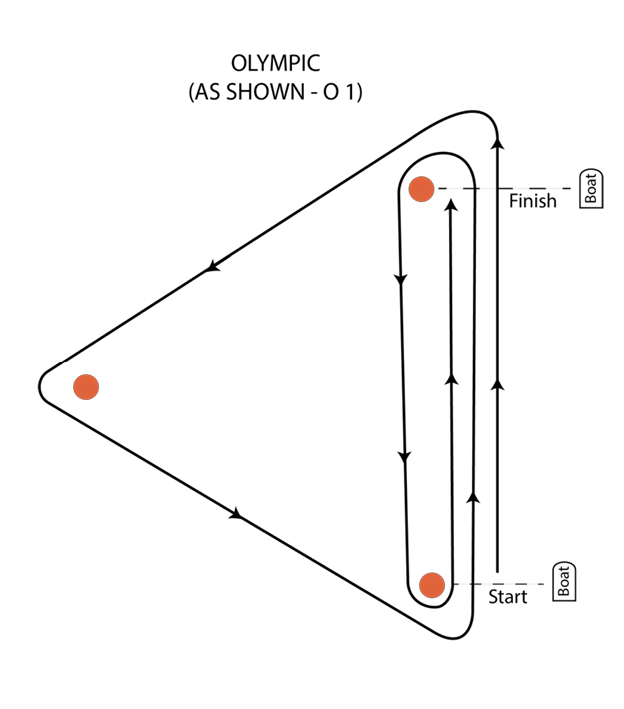

In [4]:
from IPython.display import Image, display

display(
    Image(
        "/content/drive/MyDrive/tiny_tackers/images/olympic_triangle.png",
        width=300
    )
)

In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Confirm my repo location
%cd "/content/drive/My Drive/tiny_tackers"
!pwd

/content/drive/My Drive/tiny_tackers
/content/drive/My Drive/tiny_tackers


In [7]:
# Install Stable Baselines3 library if not already installed
!pip install stable-baselines3 gymnasium pygame

In [8]:
# Confirm necessary libraries and imports are installed if they weren't already
import os
import sys
import time
import pandas as pd
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env
from gymnasium.wrappers import RecordVideo

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# Set Path to the gym_sail_steps environments
STEPS_ENV_PATH = "/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps"
sys.path.append(STEPS_ENV_PATH)

In [10]:
# IMPORTANT! Import steps environments and ensure it's coming from the correct path. Ending in tiny_tackers/gym_sailing_environments/gym_sailing_race/gym_sail_race/__init__.py
import gym_sail_steps
print(gym_sail_steps.__file__)

/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sail_steps/gym_sail_steps/__init__.py


In [11]:
# Identify the environment to call for this section
ENV_ID = "SailboatTriangle-v0"

In [12]:
# Make folders for outcomes if folders do not already exist.
models_dir = "models/ppo/triangle_race_step"
videos_dir = "videos/ppo/traingle_race_step"
metrics_dir = "metrics"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(videos_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

In [13]:
# Define the make environment function environments (render mode is none because visualizing significantly slows down training and evaluation)
def make_env(render_mode=None):
    env = gym.make(ENV_ID, render_mode=render_mode)
    env = Monitor(env)
    return env


In [14]:
# Improve efficiency with parallel environments, create your training environment
from stable_baselines3.common.env_util import make_vec_env
train_env = make_vec_env(lambda: make_env(), n_envs=4)

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

In [15]:
# Make evaluation environment
eval_env = make_env()

In [16]:
# Loading previously trained model ( you should select this yourself; what I have below is what I chose from the last step)
model = PPO.load("models/ppo/downwind_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K_downwind_500K.zip", env=train_env)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
# Train PPO for 500K timesteps and save the training time in seconds,
start = time.time()

model.learn(
    total_timesteps= 500_000,
    progress_bar=True,
)

training_time_seconds = time.time() - start

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

In [23]:
# Evaluate and capture average episode length and rewards over 20 episodes
episode_rewards, episode_lengths = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
)

mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = pd.Series(episode_rewards).std()

mean_episode_timesteps = sum(episode_lengths) / len(episode_lengths)
std_episode_timesteps = pd.Series(episode_lengths).std()

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)
print("Mean episode timesteps:", mean_episode_timesteps)
print("Std episode timesteps:", std_episode_timesteps)
print("Training time seconds:", training_time_seconds)

Mean reward: -409.72631979999994
Std reward: 14.324541952488808
Mean episode timesteps: 10000.0
Std episode timesteps: 0.0
Training time seconds: 718.909633398056


In [24]:
# Save the model
model_path = f"{models_dir}/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K_downwind_500K_triangle_1M"
model.save(model_path)

print(f"Saved model to: {model_path}.zip")

Saved model to: models/ppo/triangle_race_step/ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K_downwind_500K_triangle_1M.zip


In [25]:
# Save metrics
metrics = pd.DataFrame([{
    "env_id": ENV_ID,
    "model": "PPO",
    "training_timesteps": 1_000_000,
    "n_eval_episodes": 20,
    "mean_reward": mean_reward,
    "std_reward": std_reward,
    "mean_episode_timesteps": mean_episode_timesteps,
    "std_episode_timesteps": std_episode_timesteps,
    "training_time_seconds": training_time_seconds,
}])

metrics_path = f"{metrics_dir}/ppo_triangle_metrics.csv"

if os.path.exists(metrics_path):
    old = pd.read_csv(metrics_path)
    metrics = pd.concat([old, metrics], ignore_index=True)

metrics.to_csv(metrics_path, index=False)
metrics

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,env_id,model,training_timesteps,n_eval_episodes,mean_reward,std_reward,mean_episode_timesteps,std_episode_timesteps,training_time_seconds
0,SailboatTriangle-v0,PPO,500000,20,848.65890,321.219774,10000.0,0.0,677.155597
1,SailboatTriangle-v0,PPO,1000000,20,-409.72632,14.324542,10000.0,0.0,718.909633


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
# Record video an evaluation episode of the trained model and save it in the videos directory with a name prefix of ppo_base_trained. The video should be saved as a mp4 file and should be named ppo_base_trained_episode_0.mp4.
video_env = gym.make(ENV_ID, render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=videos_dir,
    name_prefix="ppo_upwind_1M_windwardtoreach_250K_reachtoleeward_250K_reachrounding_250K_upwind_500K_downwind_500K_triangle_1M",
    episode_trigger=lambda episode_id: episode_id == 0,
)

obs, info = video_env.reset()
done = False
truncated = False

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
video_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/tiny_tackers/videos/ppo/traingle_race_step folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
